In [1]:
import pandas as pd
data = pd.read_csv("cleaned_data.csv")
data.head(5)

,Severity,Distance(mi),Description,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Visibility(mi),Wind_Direction,Wind_Speed(mph),...,Give_Way,Junction,Railway,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,3,0.0,Two lanes blocked due to crash on I-15 Northbo...,2022-04-21 18:19:00,74.0,74.0,13.0,5.0,SW,14.0,...,False,False,False,False,False,False,Day,Day,Day,Day
1,3,0.0,#1 lane blocked due to accident on I-405 North...,2021-10-11 18:43:00,65.0,65.0,18.0,4.0,N,20.0,...,False,False,False,False,False,False,Night,Day,Day,Day
2,3,0.0,Left lane blocked due to accident on I-15 Sout...,2021-09-20 05:56:00,50.0,50.0,59.0,10.0,NNW,15.0,...,False,False,False,False,False,False,Night,Night,Night,Day
3,3,0.0,Two lanes blocked due to accident on US-75 Cen...,2021-01-30 18:53:00,70.0,70.0,17.0,4.0,W,9.0,...,False,False,False,False,False,False,Night,Night,Night,Day
4,3,0.0,Accident on Stemmons Fwy Svrd Northbound at In...,2020-10-12 08:53:00,72.0,72.0,41.0,6.0,N,12.0,...,False,False,False,False,False,True,Day,Day,Day,Day


In [2]:
data.dtypes.unique()

array([dtype('int64'), dtype('float64'), dtype('O'), dtype('bool')],
      dtype=object)

## Lets Create New DataFrame of PreProcessed Data

In [4]:
processed_data = pd.DataFrame()

# Remove Outliers
### Distance(mi), Tempreture(F), Wind_Chill(F), Humidity(%), Visibility(mi), Wind_Speed(mph) shows outliers presents in EDA

In [6]:
from feature_engine.outliers import Winsorizer

In [7]:
winsor = Winsorizer(capping_method='iqr', tail='both', fold=1.5)

<Axes: ylabel='Distance(mi)'>

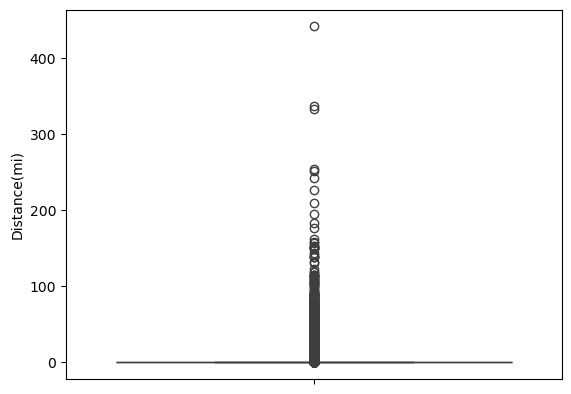

In [8]:
from seaborn import boxplot
boxplot(data['Distance(mi)'])

<Axes: >

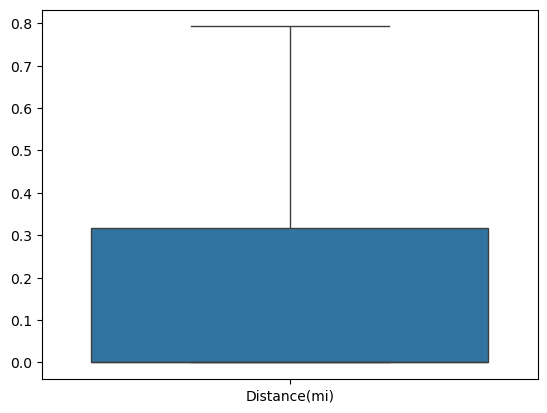

In [9]:
boxplot(winsor.fit_transform(data[['Distance(mi)']]))

### From above simulation we can clearly see that Winsorizer are capable to remove Outliers
### Now select the numerical colums from the dataframe and use winsorizer to remove the outliers

In [11]:
num_cols = list(data.select_dtypes(include='number').columns)[1:]
print(num_cols)

['Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']


In [12]:
for col in num_cols:
    processed_data[col.lower()] = winsor.fit_transform(data[[col]])

<Axes: ylabel='wind_chill(f)'>

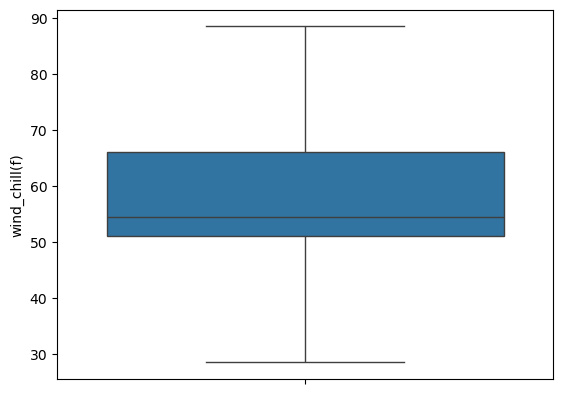

In [13]:
boxplot(processed_data['wind_chill(f)'])

### Now we have succesfully remove outliers from the dataframe

# Encoding Object Dtype
### Lets find the such feature which have object type to encode them into numerical value

In [16]:
obj_col = list(data.select_dtypes(include='object').columns)
print(obj_col)

['Description', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


#### From above Description and Weather_Timestamp could be Object dtype but they need other encoding technique which we will do in further step

In [18]:
obj_col = obj_col[2:]
print(obj_col)

['Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


### Importing Label Ecoder From Sklearn and create separate Object for seperate feature

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
wind_direction_encoder = LabelEncoder().fit(data.Wind_Direction)
weather_condition_encoder = LabelEncoder().fit(data.Weather_Condition)
sunrise_sunset_encoder  = LabelEncoder().fit(data.Sunrise_Sunset)
civil_twilight_encoder = LabelEncoder().fit(data.Civil_Twilight)
nautical_twilight_encoder = LabelEncoder().fit(data.Nautical_Twilight)
astronomical_twilight_encoder = LabelEncoder().fit(data.Astronomical_Twilight)

In [22]:
processed_data['wind_direction'] = wind_direction_encoder.transform(data.Wind_Direction)
processed_data['weather_condition'] = weather_condition_encoder.transform(data.Weather_Condition)
processed_data['surise_sunset'] = sunrise_sunset_encoder.transform(data.Sunrise_Sunset)
processed_data['civil_twilight'] = civil_twilight_encoder.transform(data.Civil_Twilight) # Day : 0 , Night : 1
processed_data['nautical_twilight'] = nautical_twilight_encoder.transform(data.Nautical_Twilight) # Day : 0 , Night : 1
processed_data['astronomical_twilight'] = astronomical_twilight_encoder.transform(data.Astronomical_Twilight) # Day : 0 , Night : 1

In [23]:
print(processed_data)

         distance(mi)  temperature(f)  wind_chill(f)  humidity(%)  \
0              0.0000            74.0           74.0         13.0   
1              0.0000            65.0           65.0         18.0   
2              0.0000            50.0           50.0         59.0   
3              0.0000            70.0           70.0         17.0   
4              0.0000            72.0           72.0         41.0   
...               ...             ...            ...          ...   
2339843        0.0000            37.0           28.5         82.0   
2339844        0.7925            29.0           28.5         89.0   
2339845        0.0000            36.0           28.5         73.0   
2339846        0.0000            36.0           28.5         73.0   
2339847        0.0000            33.0           28.5         89.0   

         visibility(mi)  wind_speed(mph)  wind_direction  weather_condition  \
0                   5.0            14.00              16                  0   
1            

# Encoding Boolean Dtype
### Lets find Boolean Dtype Feature from the dataset

In [25]:
bool_col = list(data.select_dtypes(include='bool').columns)
print(bool_col)

['Crossing', 'Give_Way', 'Junction', 'Railway', 'Stop', 'Traffic_Calming', 'Traffic_Signal']


In [26]:
crossing_encoder = LabelEncoder().fit(data.Crossing)
give_way_encoder = LabelEncoder().fit(data.Give_Way)
junction_encoder = LabelEncoder().fit(data.Junction)
railway_encoder = LabelEncoder().fit(data.Railway)
stop_encoder = LabelEncoder().fit(data.Stop)
traffic_calming_encoder = LabelEncoder().fit(data.Traffic_Calming)
traffic_signal_encoder = LabelEncoder().fit(data.Traffic_Signal)

In [27]:
for col in bool_col:
    encoder = globals()[f'{col.lower()}_encoder']
    processed_data[col.lower()] = encoder.transform(data[col])

## Extract Hour and Minute from Weather_Timestamp
### Using REGEX and Pattern

In [29]:
processed_data['hour'] = data['Weather_Timestamp'].str.extract(r'(\d{2}):')
processed_data['minute'] = data['Weather_Timestamp'].str.extract(r':(\d{2}):')

## Now lets Transform Description into Vectors 
### Using TFIDF Vectorizer

In [31]:
print(data.Description)

0          Two lanes blocked due to crash on I-15 Northbo...
1          #1 lane blocked due to accident on I-405 North...
2          Left lane blocked due to accident on I-15 Sout...
3          Two lanes blocked due to accident on US-75 Cen...
4          Accident on Stemmons Fwy Svrd Northbound at In...
                                 ...                        
2339843                         At Brentnell Ave - Accident.
2339844    Between IL-173/W Lane Rd and US-20-BR/State St...
2339845                   At Airport Way/Exit 24 - Accident.
2339846    At I-5/OR-43/SW Kelly Ave/SW Hood Ave - Accident.
2339847                     At OR-211/Meinig Ave - Accident.
Name: Description, Length: 2339848, dtype: object


### Create a Sentence Transformer model

In [65]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

ModuleNotFoundError: No module named 'sentence_transformers'

In [32]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# import numpy as np
# description_vectorizer = TfidfVectorizer(
#     max_features=5000,         # Reduce features for speed & memory
#     min_df=3,                  # Lower threshold to capture more words
#     max_df=0.7,                # Exclude overly frequent words
#     stop_words='english',      # Remove English stopwords
#     ngram_range=(1, 2),        # Capture unigrams + bigrams (better context)
#     sublinear_tf=True,         # Apply log-scaling to term frequency
#     dtype=np.float32           # Use 32-bit floats to reduce memory
# )

# # Fit + transform (use sparse matrix to avoid high memory usage)
# x = description_vectorizer.fit_transform(data['Description'].astype(str))

In [33]:
# col_means = np.array(x.mean(axis=0)).ravel()
# feature_names = description_vectorizer.get_feature_names_out()

# # Combine into a DataFrame
# import pandas as pd
# tfidf_feature_means = pd.DataFrame({
#     'feature': feature_names,
#     'mean_tfidf': col_means
# }).sort_values(by='mean_tfidf', ascending=False)

# print(tfidf_feature_means.head(10))
